# Task 1

### Spark Session Setup

In [1]:
from pyspark.sql import SparkSession

# Create or get the Spark session
spark = SparkSession.builder \
    .appName("Airline Delay Prediction - Project 4") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")


Spark version: 3.5.3


### Load 2009 CSV Data (Need to add 2010 when it is available)

In [2]:
# Load 2009 data as DataFrame
csv_path = "/home/jovyan/lab_data/2009.csv"

df_2009 = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("ignoreLeadingWhiteSpace", "true") \
    .option("ignoreTrailingWhiteSpace", "true") \
    .load(csv_path)

# Show a sample
df_2009.show(5)


+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+-----------+
|   FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|Unnamed: 27|
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+-----------+
|

### Write as Partitioned Parquet

In [3]:
output_path = "/home/jovyan/lab_data/2009_parquet_partitioned"

df_2009.write \
    .mode("overwrite") \
    .partitionBy("OP_CARRIER") \
    .parquet(output_path)

print("Parquet written with partitioning.")


Parquet written with partitioning.


# Task 2

### Rename Columns

In [4]:
from pyspark.sql.functions import col

df_cleaned = df_2009 \
    .withColumnRenamed("OP_CARRIER", "uniqueCarrier") \
    .withColumnRenamed("FL_DATE", "flightDate") \
    .withColumnRenamed("OP_CARRIER_FL_NUM", "flightNumber") \
    .withColumnRenamed("ORIGIN", "origin") \
    .withColumnRenamed("DEST", "dest") \
    .withColumnRenamed("CRS_DEP_TIME", "scheduledDepTime") \
    .withColumnRenamed("DEP_TIME", "actualDepTime") \
    .withColumnRenamed("DEP_DELAY", "depDelay") \
    .withColumnRenamed("TAXI_OUT", "taxiOut") \
    .withColumnRenamed("WHEELS_OFF", "wheelsOff") \
    .withColumnRenamed("WHEELS_ON", "wheelsOn") \
    .withColumnRenamed("TAXI_IN", "taxiIn") \
    .withColumnRenamed("CRS_ARR_TIME", "scheduledArrTime") \
    .withColumnRenamed("ARR_TIME", "actualArrTime") \
    .withColumnRenamed("ARR_DELAY", "arrDelay") \
    .withColumnRenamed("CANCELLED", "cancelled") \
    .withColumnRenamed("CANCELLATION_CODE", "cancellationCode") \
    .withColumnRenamed("DIVERTED", "diverted") \
    .withColumnRenamed("CRS_ELAPSED_TIME", "scheduledElapsedTime") \
    .withColumnRenamed("ACTUAL_ELAPSED_TIME", "actualElapsedTime") \
    .withColumnRenamed("AIR_TIME", "airTime") \
    .withColumnRenamed("DISTANCE", "distance") \
    .withColumnRenamed("CARRIER_DELAY", "carrierDelay") \
    .withColumnRenamed("WEATHER_DELAY", "weatherDelay") \
    .withColumnRenamed("NAS_DELAY", "nasDelay") \
    .withColumnRenamed("SECURITY_DELAY", "securityDelay") \
    .withColumnRenamed("LATE_AIRCRAFT_DELAY", "lateAircraftDelay")


In [5]:
df_cleaned = df_cleaned.drop("Unnamed: 27")


In [6]:
df_cleaned.columns


['flightDate',
 'uniqueCarrier',
 'flightNumber',
 'origin',
 'dest',
 'scheduledDepTime',
 'actualDepTime',
 'depDelay',
 'taxiOut',
 'wheelsOff',
 'wheelsOn',
 'taxiIn',
 'scheduledArrTime',
 'actualArrTime',
 'arrDelay',
 'cancelled',
 'cancellationCode',
 'diverted',
 'scheduledElapsedTime',
 'actualElapsedTime',
 'airTime',
 'distance',
 'carrierDelay',
 'weatherDelay',
 'nasDelay',
 'securityDelay',
 'lateAircraftDelay']

### Extract DayOfWeek and Month from flightDate

In [7]:
from pyspark.sql.functions import to_date, dayofweek, month

# Ensure flightDate is in date format
df_cleaned = df_cleaned.withColumn("flightDate", to_date("flightDate"))

# Add DayOfWeek (1 = Sunday, 7 = Saturday) and Month
df_cleaned = df_cleaned.withColumn("dayOfWeek", dayofweek("flightDate")) \
                       .withColumn("month", month("flightDate"))

df_cleaned.select("flightDate", "dayOfWeek", "month").show(5)

+----------+---------+-----+
|flightDate|dayOfWeek|month|
+----------+---------+-----+
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
+----------+---------+-----+
only showing top 5 rows



### Missing values

In [8]:
from pyspark.sql.functions import col

for _col in df_cleaned.columns:
    nulls = df_cleaned.filter(col(_col).isNull())
    if nulls.count() > 0:
        print(_col, nulls.count())

actualDepTime 82867
depDelay 82867
taxiOut 85787
wheelsOff 85787
wheelsOn 89322
taxiIn 89321
actualArrTime 89322
arrDelay 102361
cancellationCode 6342300
actualElapsedTime 102362
airTime 102361
carrierDelay 5258837
weatherDelay 5258837
nasDelay 5258837
securityDelay 5258837
lateAircraftDelay 5258837


In [9]:
df_cleaned = df_cleaned.filter(col("flightDate").isNotNull())
print(f"Remaining rows after dropping only null flightDate: {df_cleaned.count()}")

Remaining rows after dropping only null flightDate: 6429338


In [10]:
df_cleaned = df_cleaned.fillna(0, subset=[
    "dayOfWeek", "month",
    "actualDepTime", "taxiOut", "wheelsOff", "wheelsOn",
    "taxiIn", "actualArrTime", "actualElapsedTime", "airTime", "depDelay", "arrDelay", "carrierDelay", "weatherDelay", "nasDelay",
    "securityDelay", "lateAircraftDelay"
])
df_cleaned = df_cleaned.fillna("-", subset=["cancellationCode"])

### Filter out diverted flights (diverted == 1)

In [11]:
df_cleaned = df_cleaned.filter(col("diverted") == 0)

print(f"Row count after filtering diverted flights: {df_cleaned.count()}")


Row count after filtering diverted flights: 6414015


# Task 3

### Top 10 Carriers by Flight Count

In [12]:
df_cleaned.groupBy("uniqueCarrier") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)


+-------------+-------+
|uniqueCarrier|  count|
+-------------+-------+
|           WN|1127045|
|           AA| 548194|
|           OO| 544843|
|           MQ| 434577|
|           DL| 424982|
|           US| 411274|
|           UA| 375501|
|           XE| 308340|
|           EV| 297874|
|           NW| 291856|
+-------------+-------+
only showing top 10 rows



### Visualize Cancellation Reasons

In [13]:
cancelled_df = df_cleaned.filter("cancelled == 1 AND cancellationCode IS NOT NULL") \
                         .select("flightDate", "uniqueCarrier", "origin", "dest", "cancellationCode") \
                         .toPandas()

cancelled_df.head(10)


,flightDate,uniqueCarrier,origin,dest,cancellationCode
0,2009-01-01,YV,DEN,CPR,A
1,2009-01-01,YV,DTW,ORD,A
2,2009-01-01,YV,EWR,IAD,A
3,2009-01-01,YV,FAT,LAS,B
4,2009-01-01,YV,FAT,PHX,B
5,2009-01-01,YV,MLI,ORD,A
6,2009-01-01,YV,SBA,PHX,B
7,2009-01-01,YV,SBA,PHX,B
8,2009-01-01,OO,ATL,MOB,A
9,2009-01-01,OO,MOB,ATL,A


In [14]:
df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+----------------+-----+
|cancellationCode|count|
+----------------+-----+
|               B|36651|
|               A|35568|
|               C|14799|
|               D|   20|
+----------------+-----+



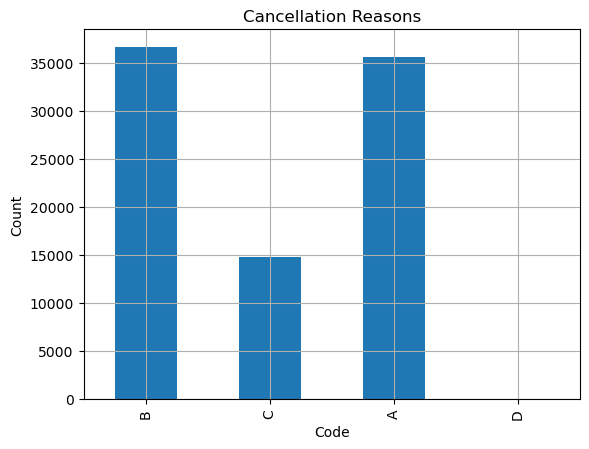

In [15]:
# Convert to Pandas for visualization
cancel_reasons = df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .toPandas()

# Plot
import matplotlib.pyplot as plt

cancel_reasons.set_index("cancellationCode").plot(kind="bar", legend=False)
plt.title("Cancellation Reasons")
plt.ylabel("Count")
plt.xlabel("Code")
plt.grid(True)
plt.show()


### Class Distribution for cancelled

In [16]:
df_cleaned.groupBy("cancelled").count().show()


+---------+-------+
|cancelled|  count|
+---------+-------+
|      0.0|6326977|
|      1.0|  87038|
+---------+-------+



In [17]:
cancel_counts = df_cleaned.groupBy("cancelled").count().collect()
cancel_0 = next(r["count"] for r in cancel_counts if r["cancelled"] == 0.0)
cancel_1 = next(r["count"] for r in cancel_counts if r["cancelled"] == 1.0)

imbalance_ratio = cancel_0 / cancel_1 if cancel_1 else float("inf")
print(f"Imbalance ratio (non-cancelled : cancelled) = {imbalance_ratio:.2f} : 1")


Imbalance ratio (non-cancelled : cancelled) = 72.69 : 1


# Task 4

### Feature Selection

In [18]:
categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]


### Encoding Categorical Columns

In [19]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# Index and encode each categorical feature
indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]


### Combine with VectorAssembler

In [20]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[col+"_vec" for col in categorical_cols] + numeric_cols,
    outputCol="features"
)


### Full Feature Pipeline

In [21]:
from pyspark.ml import Pipeline

# All transformations in one pipeline
feature_pipeline = Pipeline(stages=indexers + encoders + [assembler])

# Apply the pipeline
df_featurized = feature_pipeline.fit(df_cleaned).transform(df_cleaned)

# Preview final features
df_featurized.select("features", "cancelled").show(5, truncate=False)


+---------------------------------------------------------+---------+
|features                                                 |cancelled|
+---------------------------------------------------------+---------+
|(614,[7,42,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1100.0])|0.0      |
|(614,[7,33,341,611,612,613],[1.0,1.0,1.0,1.0,5.0,1510.0])|0.0      |
|(614,[7,33,338,611,612,613],[1.0,1.0,1.0,1.0,5.0,1100.0])|0.0      |
|(614,[7,42,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1240.0])|0.0      |
|(614,[7,45,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1715.0])|0.0      |
+---------------------------------------------------------+---------+
only showing top 5 rows



# Task 5

### Rename cancelled to label

In [22]:
# Only needed once, after feature engineering
df_model_input = df_featurized.withColumnRenamed("cancelled", "label")


### Sample the Data

In [23]:
# Use 10% of the data to reduce memory load
df_sample = df_model_input.sample(fraction=0.1, seed=42)


### Train/Test Split

In [24]:
train_df, test_df = df_sample.randomSplit([0.7, 0.3], seed=42)


### Train Logistic Regression

In [25]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=10)
lr_model = lr.fit(train_df)


### Make Predictions on Test Set

In [26]:
predictions = lr_model.transform(test_df)
predictions.select("label", "prediction", "probability").show(5, truncate=False)


+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |0.0       |[0.983560481803932,0.016439518196068037] |
|0.0  |0.0       |[0.955098047983405,0.04490195201659497]  |
|0.0  |0.0       |[0.9847159343787226,0.015284065621277376]|
|0.0  |0.0       |[0.9837241535136851,0.01627584648631486] |
|0.0  |0.0       |[0.9850361638851118,0.014963836114888163]|
+-----+----------+-----------------------------------------+
only showing top 5 rows



### Evaluate AUC and Accuracy

In [27]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.sql.functions import col
from pyspark.sql.functions import to_date, dayofweek, month
from pyspark.sql.functions import col
csv_path = "/home/jovyan/lab_data/2009.csv"

df_2009 = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("ignoreLeadingWhiteSpace", "true") \
    .option("ignoreTrailingWhiteSpace", "true") \
    .load(csv_path)

# Show a sample
df_2009.show(5)
output_path = "/home/jovyan/lab_data/2009_parquet_partitioned"

df_2009.write \
    .mode("overwrite") \
    .partitionBy("OP_CARRIER") \
    .parquet(output_path)

print("Parquet written with partitioning.")

df_cleaned = df_2009 \
    .withColumnRenamed("OP_CARRIER", "uniqueCarrier") \
    .withColumnRenamed("FL_DATE", "flightDate") \
    .withColumnRenamed("OP_CARRIER_FL_NUM", "flightNumber") \
    .withColumnRenamed("ORIGIN", "origin") \
    .withColumnRenamed("DEST", "dest") \
    .withColumnRenamed("CRS_DEP_TIME", "scheduledDepTime") \
    .withColumnRenamed("DEP_TIME", "actualDepTime") \
    .withColumnRenamed("DEP_DELAY", "depDelay") \
    .withColumnRenamed("TAXI_OUT", "taxiOut") \
    .withColumnRenamed("WHEELS_OFF", "wheelsOff") \
    .withColumnRenamed("WHEELS_ON", "wheelsOn") \
    .withColumnRenamed("TAXI_IN", "taxiIn") \
    .withColumnRenamed("CRS_ARR_TIME", "scheduledArrTime") \
    .withColumnRenamed("ARR_TIME", "actualArrTime") \
    .withColumnRenamed("ARR_DELAY", "arrDelay") \
    .withColumnRenamed("CANCELLED", "cancelled") \
    .withColumnRenamed("CANCELLATION_CODE", "cancellationCode") \
    .withColumnRenamed("DIVERTED", "diverted") \
    .withColumnRenamed("CRS_ELAPSED_TIME", "scheduledElapsedTime") \
    .withColumnRenamed("ACTUAL_ELAPSED_TIME", "actualElapsedTime") \
    .withColumnRenamed("AIR_TIME", "airTime") \
    .withColumnRenamed("DISTANCE", "distance") \
    .withColumnRenamed("CARRIER_DELAY", "carrierDelay") \
    .withColumnRenamed("WEATHER_DELAY", "weatherDelay") \
    .withColumnRenamed("NAS_DELAY", "nasDelay") \
    .withColumnRenamed("SECURITY_DELAY", "securityDelay") \
    .withColumnRenamed("LATE_AIRCRAFT_DELAY", "lateAircraftDelay")

df_cleaned = df_cleaned.drop("Unnamed: 27")

# Ensure flightDate is in date format
df_cleaned = df_cleaned.withColumn("flightDate", to_date("flightDate"))

# Add DayOfWeek (1 = Sunday, 7 = Saturday) and Month
df_cleaned = df_cleaned.withColumn("dayOfWeek", dayofweek("flightDate")) \
                       .withColumn("month", month("flightDate"))

df_cleaned.select("flightDate", "dayOfWeek", "month").show(5)
for _col in df_cleaned.columns:
    nulls = df_cleaned.filter(col(_col).isNull())
    if nulls.count() > 0:
        print(_col, nulls.count())
df_cleaned = df_cleaned.filter(col("flightDate").isNotNull())
print(f"Remaining rows after dropping only null flightDate: {df_cleaned.count()}")
df_cleaned = df_cleaned.fillna(0, subset=[
    "dayOfWeek", "month",
    "actualDepTime", "taxiOut", "wheelsOff", "wheelsOn",
    "taxiIn", "actualArrTime", "actualElapsedTime", "airTime", "depDelay", "arrDelay", "carrierDelay", "weatherDelay", "nasDelay",
    "securityDelay", "lateAircraftDelay"
])
df_cleaned = df_cleaned.fillna("-", subset=["cancellationCode"])
df_cleaned = df_cleaned.filter(col("diverted") == 0)

print(f"Row count after filtering diverted flights: {df_cleaned.count()}")

df_cleaned.groupBy("uniqueCarrier") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)

cancelled_df = df_cleaned.filter("cancelled == 1 AND cancellationCode IS NOT NULL") \
                         .select("flightDate", "uniqueCarrier", "origin", "dest", "cancellationCode") \
                         .toPandas()

cancelled_df.head(10)

df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

# Convert to Pandas for visualization
cancel_reasons = df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .toPandas()

# Plot
import matplotlib.pyplot as plt

cancel_reasons.set_index("cancellationCode").plot(kind="bar", legend=False)
plt.title("Cancellation Reasons")
plt.ylabel("Count")
plt.xlabel("Code")
plt.grid(True)
plt.show()

df_cleaned.groupBy("cancelled").count().show()

cancel_counts = df_cleaned.groupBy("cancelled").count().collect()
cancel_0 = next(r["count"] for r in cancel_counts if r["cancelled"] == 0.0)
cancel_1 = next(r["count"] for r in cancel_counts if r["cancelled"] == 1.0)

imbalance_ratio = cancel_0 / cancel_1 if cancel_1 else float("inf")
print(f"Imbalance ratio (non-cancelled : cancelled) = {imbalance_ratio:.2f} : 1")

categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]

# Index and encode each categorical feature
indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]

predictions = lr_model.transform(test_df)
predictions.select("label", "prediction", "probability").show(5, truncate=False)

# AUC
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator_auc.evaluate(predictions)

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acc = evaluator_acc.evaluate(predictions)

print(f"Logistic Regression AUC: {auc:.4f}, Accuracy: {acc:.4f}")


Logistic Regression AUC: 0.7001, Accuracy: 0.9864


### Decision Tree Classifier

In [43]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=5)
dt_model = dt.fit(train_df)

dt_predictions = dt_model.transform(test_df)

# Evaluation
dt_auc = evaluator_auc.evaluate(dt_predictions)
dt_acc = evaluator_acc.evaluate(dt_predictions)
print(f"Decision Tree AUC: {dt_auc:.4f}, Accuracy: {dt_acc:.4f}")


Decision Tree AUC: 0.4514, Accuracy: 0.9864


### Random Forest Classifier

In [44]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50)
rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

# Evaluation
rf_auc = evaluator_auc.evaluate(rf_predictions)
rf_acc = evaluator_acc.evaluate(rf_predictions)
print(f"Random Forest AUC: {rf_auc:.4f}, Accuracy: {rf_acc:.4f}")


Random Forest AUC: 0.6263, Accuracy: 0.9864


### Gradient Boosted Trees (GBT)

In [45]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
gbt_model = gbt.fit(train_df)

gbt_predictions = gbt_model.transform(test_df)

# Evaluation
gbt_auc = evaluator_auc.evaluate(gbt_predictions)
gbt_acc = evaluator_acc.evaluate(gbt_predictions)
print(f"GBT AUC: {gbt_auc:.4f}, Accuracy: {gbt_acc:.4f}")


GBT AUC: 0.7101, Accuracy: 0.9864


### Store Results in a Table

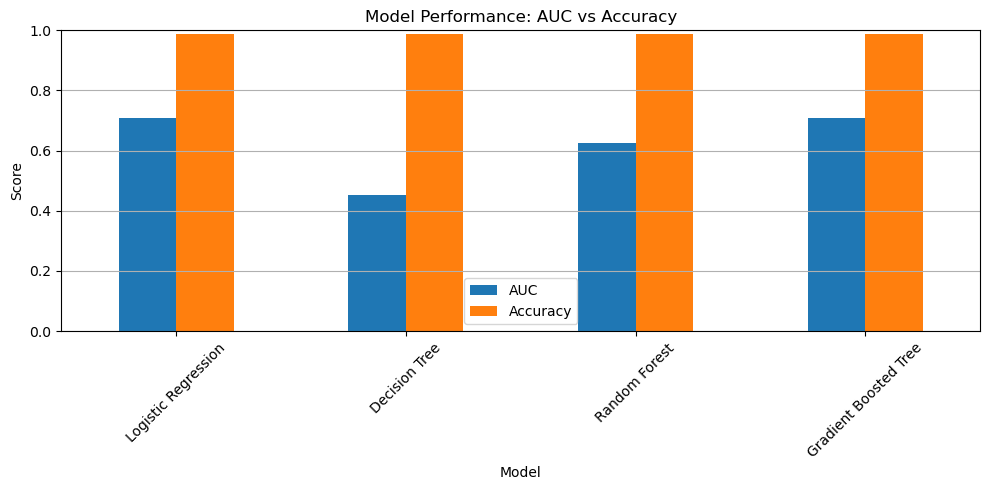

In [46]:
results = [
    {"Model": "Logistic Regression", "AUC": auc, "Accuracy": acc},
    {"Model": "Decision Tree", "AUC": dt_auc, "Accuracy": dt_acc},
    {"Model": "Random Forest", "AUC": rf_auc, "Accuracy": rf_acc},
    {"Model": "Gradient Boosted Tree", "AUC": gbt_auc, "Accuracy": gbt_acc},
]

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
results_df.set_index("Model")[["AUC", "Accuracy"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance: AUC vs Accuracy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### CrossValidation

In [30]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Feature columns
categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]

# Feature pipeline
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idxs", handleInvalid="keep") for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=c+"_idxs", outputCol=c+"_vecs") for c in categorical_cols]
assembler = VectorAssembler(
    inputCols=[c + "_vec" for c in categorical_cols] + numeric_cols,
    outputCol="featuress"
)

# Sample and split
df_sample = df_model_input.sample(fraction=0.1, seed=42)
train_df, test_df = df_sample.randomSplit([0.7, 0.3], seed=42)

# Evaluator
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
# Models and param grids
models = [
    {
        "name": "Logistic Regression",
        "estimator": LogisticRegression(labelCol="label", featuresCol="featuress", maxIter=10),
        "paramGrid": ParamGridBuilder().addGrid(LogisticRegression.regParam, [0.01, 0.1, 1.0]).build()
    },
    {
        "name": "Decision Tree",
        "estimator": DecisionTreeClassifier(labelCol="label", featuresCol="featuress"),
        "paramGrid": ParamGridBuilder().addGrid(DecisionTreeClassifier.maxDepth, [3, 5, 10]).build()
    },
    {
        "name": "Random Forest",
        "estimator": RandomForestClassifier(labelCol="label", featuresCol="featuress"),
        "paramGrid": ParamGridBuilder().addGrid(RandomForestClassifier.numTrees, [20, 50]).build()
    },
    {
        "name": "Gradient Boosted Tree",
        "estimator": GBTClassifier(labelCol="label", featuresCol="features", maxIter=20),
        "paramGrid": ParamGridBuilder().addGrid(GBTClassifier.maxDepth, [3, 5]).build()
    }
]

# Run CV for each model
results = []
for model in models:
    print(f"\nTraining {model['name']}...")
    pipeline = Pipeline(stages=indexers + encoders + [assembler, model["estimator"]])
    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=model["paramGrid"],
        evaluator=evaluator,
        numFolds=3
    )
    cv_model = cv.fit(train_df)
    predictions = cv_model.transform(test_df)
    auc = evaluator.evaluate(predictions)
    print(f"{model['name']} AUC: {auc:.4f}")
    results.append((model["name"], auc))


Training Logistic Regression...
Logistic Regression AUC: 0.7001

Training Decision Tree...
Decision Tree AUC: 0.4514

Training Random Forest...
Random Forest AUC: 0.6260

Training Gradient Boosted Tree...
Gradient Boosted Tree AUC: 0.7101


# Task 6

In [32]:
best_model = cv_model.bestModel.stages[-1]

In [33]:
best_model

GBTClassificationModel: uid = GBTClassifier_930b33ed5596, numTrees=20, numClasses=2, numFeatures=614

In [36]:
categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]

# Estimate category cardinalities (for OneHotEncoder expansion)
feature_names = []
for col in categorical_cols:
    count = df_cleaned.select(col).distinct().count()
    feature_names.extend([f"{col}_{i}" for i in range(count)])

# Add numeric feature names directly
feature_names.extend(numeric_cols)


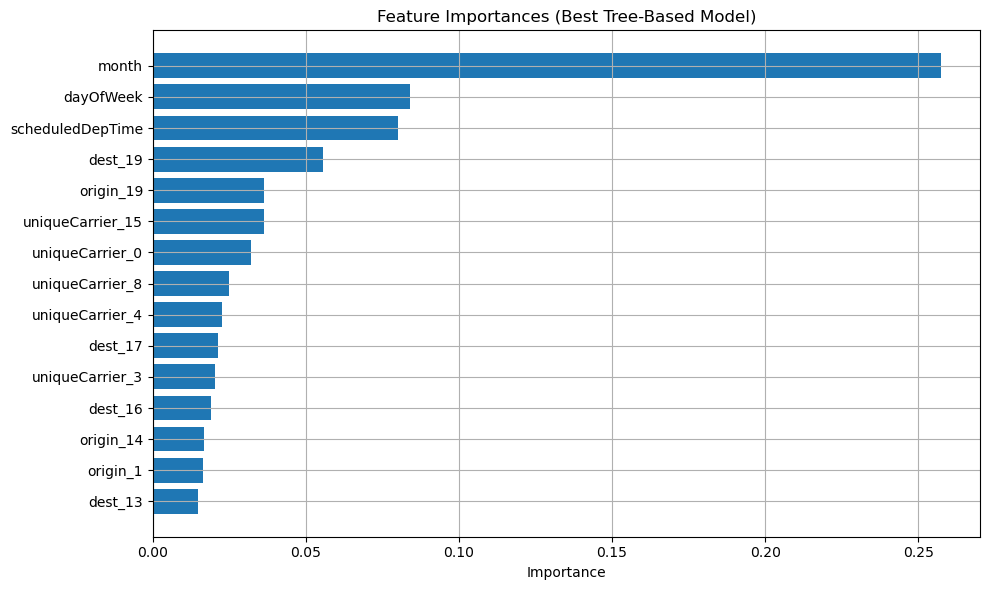

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract from best model (e.g., RF or GBT)
importances = best_model.featureImportances.toArray()

# Match lengths
N = min(len(importances), len(feature_names))
feat_imp_df = pd.DataFrame({
    "Feature": feature_names[:N],
    "Importance": importances[:N]
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df["Feature"][:15][::-1], feat_imp_df["Importance"][:15][::-1])
plt.xlabel("Importance")
plt.title("Feature Importances (Best Tree-Based Model)")
plt.tight_layout()
plt.grid(True)
plt.show()

# Task 7

In [51]:
cv_model.bestModel.write().overwrite().save("/home/jovyan/model")

In [52]:
from pyspark.ml.pipeline import PipelineModel
loaded_model = PipelineModel.load("/home/jovyan/model")

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.sql.functions import col
from pyspark.sql.functions import to_date, dayofweek, month
from pyspark.sql.functions import col

csv_2010_path = "/home/jovyan/lab_data/2010.csv"

df_2010 = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("ignoreLeadingWhiteSpace", "true") \
    .option("ignoreTrailingWhiteSpace", "true") \
    .load(csv_2010_path)

output_2010_path = "/home/jovyan/lab_data/2010_parquet_partitioned"

df_2010.write \
    .mode("overwrite") \
    .partitionBy("OP_CARRIER") \
    .parquet(output_2010_path)

print("Parquet written with partitioning.")

df_cleaned_2 = df_2010 \
    .withColumnRenamed("OP_CARRIER", "uniqueCarrier") \
    .withColumnRenamed("FL_DATE", "flightDate") \
    .withColumnRenamed("OP_CARRIER_FL_NUM", "flightNumber") \
    .withColumnRenamed("ORIGIN", "origin") \
    .withColumnRenamed("DEST", "dest") \
    .withColumnRenamed("CRS_DEP_TIME", "scheduledDepTime") \
    .withColumnRenamed("DEP_TIME", "actualDepTime") \
    .withColumnRenamed("DEP_DELAY", "depDelay") \
    .withColumnRenamed("TAXI_OUT", "taxiOut") \
    .withColumnRenamed("WHEELS_OFF", "wheelsOff") \
    .withColumnRenamed("WHEELS_ON", "wheelsOn") \
    .withColumnRenamed("TAXI_IN", "taxiIn") \
    .withColumnRenamed("CRS_ARR_TIME", "scheduledArrTime") \
    .withColumnRenamed("ARR_TIME", "actualArrTime") \
    .withColumnRenamed("ARR_DELAY", "arrDelay") \
    .withColumnRenamed("CANCELLED", "cancelled") \
    .withColumnRenamed("CANCELLATION_CODE", "cancellationCode") \
    .withColumnRenamed("DIVERTED", "diverted") \
    .withColumnRenamed("CRS_ELAPSED_TIME", "scheduledElapsedTime") \
    .withColumnRenamed("ACTUAL_ELAPSED_TIME", "actualElapsedTime") \
    .withColumnRenamed("AIR_TIME", "airTime") \
    .withColumnRenamed("DISTANCE", "distance") \
    .withColumnRenamed("CARRIER_DELAY", "carrierDelay") \
    .withColumnRenamed("WEATHER_DELAY", "weatherDelay") \
    .withColumnRenamed("NAS_DELAY", "nasDelay") \
    .withColumnRenamed("SECURITY_DELAY", "securityDelay") \
    .withColumnRenamed("LATE_AIRCRAFT_DELAY", "lateAircraftDelay") \
    .drop("Unnamed: 27") \
    .withColumn("flightDate", to_date("flightDate"))

df_cleaned_2 = df_cleaned_2.withColumn("dayOfWeek", dayofweek("flightDate")) \
                       .withColumn("month", month("flightDate"))

df_cleaned = df_cleaned.fillna("-", subset=["cancellationCode"])
df_cleaned = df_cleaned_2.fillna(0)

categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]

indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]

predictions = lr_model.transform(test_df)
predictions.select("label", "prediction", "probability").show(5, truncate=False)

# AUC
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator_auc.evaluate(predictions)

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acc = evaluator_acc.evaluate(predictions)

print(f"Logistic Regression AUC: {auc:.4f}, Accuracy: {acc:.4f}")


In [ ]:
predictions_2010 = loaded_model.transform(df_2010)

In [ ]:
predictions_2010.select("uniqueCarrier", "origin", "dest", "scheduledDepTime", "prediction", "probability").show(10, truncate=False)

In [ ]:
if "cancelled" in df_2010.columns:
    evaluator = BinaryClassificationEvaluator(labelCol="cancelled", metricName="areaUnderROC")
    auc_2010 = evaluator.evaluate(predictions_2010)
    print(f"AUC on 2010 data: {auc_2010:.4f}")